# ARB Airdrop: Early-Outflow Charts

## tl;dr

- **78.8%** of validated claim recipients had at least one positive non-self ARB outflow within 24 hours; **85.5%** did so within seven days.
- **60.8%** had their first positive outflow within one hour, while **14.5%** had no positive outflow during the first seven days.
- The capped claim-linked outflow proxy reached **73.0%** of claimed ARB within 24 hours and **80.4%** within seven days.

These are transfer-based early-outflow measures, **not sales measures**. Destinations are not classified in this notebook.

## Context & Methods

This companion notebook turns the validated claim-grain output into three portfolio-ready figures. It reads the small, versioned JSON artifact in `data/`; it does not query BigQuery.

### Key Assumptions

- **Cohort grain:** one validated `HasClaimed` event and unique recipient per row, 583,137 rows in total.
- **Early outflow:** a positive non-self ARB transfer ordered after the exact claim, measured in elapsed half-open windows of 24 hours and seven days.
- **Claim-linked outflow proxy:** cumulative gross outflow capped at each wallet's claim amount. Because ARB is fungible, this is a proxy rather than token-unit attribution.
- **Claim-size groups:** cut at the observed approximate cohort quartiles: 875, 1,250, and 2,250 ARB.
- **Terminology:** outgoing transfers are not described as sales without DEX or reliable exchange-destination evidence.

In [1]:
from pathlib import Path
import json

import pandas as pd
import plotly.graph_objects as go
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "early_outflow_chart_data.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/early_outflow_chart_data.json")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "early_outflow_chart_data.json"
QA_PATH = PROJECT_ROOT / "data" / "early_outflow_chart_data_qa.json"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root: <repository root>")
print(f"Data source: {DATA_PATH.relative_to(PROJECT_ROOT)}")

Project root: <repository root>
Data source: data\early_outflow_chart_data.json


## Data

The input contains two elapsed-window rows, four claim-size segments, and six mutually exclusive first-outflow timing buckets. The accompanying QA artifact must pass before any chart is rendered.

In [2]:
with DATA_PATH.open(encoding="utf-8") as file:
    chart_data = json.load(file)

with QA_PATH.open(encoding="utf-8") as file:
    chart_qa = json.load(file)

assert all(chart_qa["checks"].values()), "Chart-data QA contains a failed check."

window_df = pd.DataFrame(chart_data["window_summary"]).sort_values("window_order")
segment_df = pd.DataFrame(chart_data["claim_size_segments"]).sort_values("segment_order")
timing_df = pd.DataFrame(chart_data["first_positive_outflow_timing"]).sort_values("bucket_order")

assert len(window_df) == 2
assert len(segment_df) == 4
assert len(timing_df) == 6
assert segment_df["recipient_count"].sum() == chart_qa["claim_rows"]
assert timing_df["recipient_count"].sum() == chart_qa["claim_rows"]

pd.DataFrame(
    {
        "dataset": ["Elapsed windows", "Claim-size segments", "Timing buckets"],
        "rows": [len(window_df), len(segment_df), len(timing_df)],
        "recipient_total": [
            int(window_df["recipient_count"].max()),
            int(segment_df["recipient_count"].sum()),
            int(timing_df["recipient_count"].sum()),
        ],
    }
)

,dataset,rows,recipient_total
0,Elapsed windows,2,583137
1,Claim-size segments,4,583137
2,Timing buckets,6,583137


## Results

### 1. First-positive-outflow timing

The first chart uses mutually exclusive buckets across the complete cohort, including recipients with no positive outflow during the first seven days.

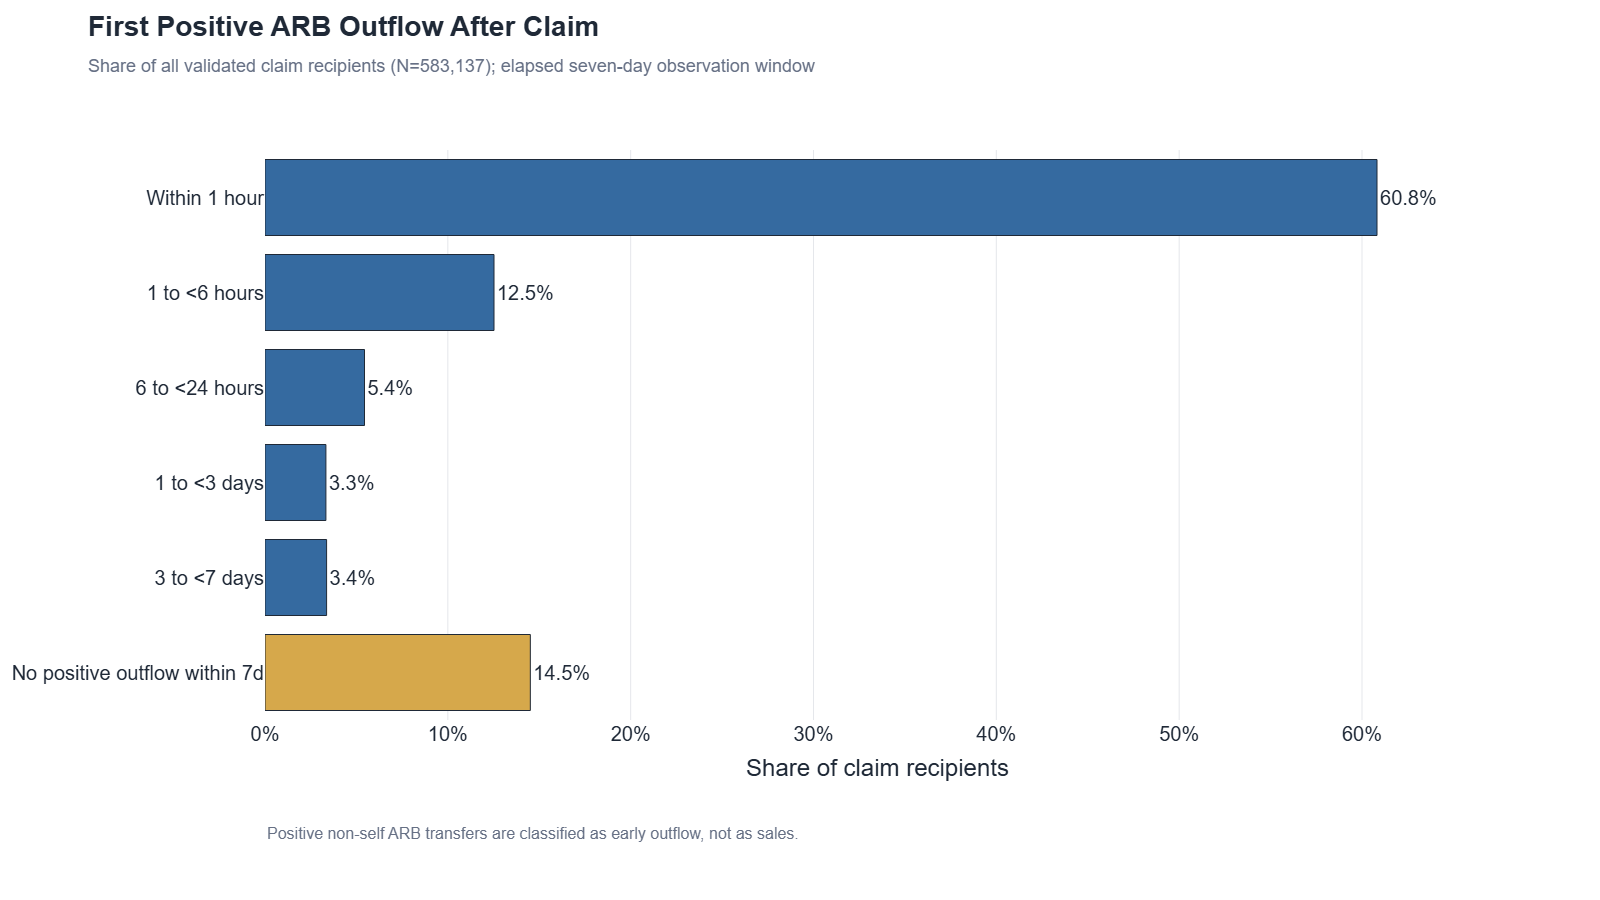

In [3]:
COLORS = {
    "blue": "#356AA0",
    "blue_light": "#A9C4E2",
    "gold": "#D6A84B",
    "ink": "#1F2937",
    "muted": "#667085",
    "grid": "#E5E7EB",
    "white": "#FFFFFF",
}


def apply_base_layout(fig, title, subtitle, height=900, bottom_note=None):
    fig.update_layout(
        width=1600,
        height=height,
        paper_bgcolor=COLORS["white"],
        plot_bgcolor=COLORS["white"],
        font=dict(family="Arial", size=20, color=COLORS["ink"]),
        title=dict(
            text=f"<b>{title}</b><br><span style='font-size:18px;color:{COLORS['muted']}'>{subtitle}</span>",
            x=0.055,
            xanchor="left",
            y=0.96,
            yanchor="top",
        ),
        margin=dict(l=185, r=110, t=150, b=180 if bottom_note else 95),
        showlegend=False,
    )
    if bottom_note:
        fig.add_annotation(
            x=0,
            y=-0.18,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="top",
            showarrow=False,
            align="left",
            font=dict(size=16, color=COLORS["muted"]),
            text=bottom_note,
        )
    return fig


def export_and_display(fig, stem):
    png_path = FIGURES_DIR / f"{stem}.png"
    svg_path = FIGURES_DIR / f"{stem}.svg"
    fig.write_image(png_path, scale=1)
    fig.write_image(svg_path)
    display(Image(data=png_path.read_bytes(), width=1100))
    return png_path, svg_path


timing_colors = [COLORS["blue"]] * 5 + [COLORS["gold"]]
timing_fig = go.Figure(
    go.Bar(
        x=timing_df["recipient_share"],
        y=timing_df["timing_bucket"],
        orientation="h",
        marker=dict(color=timing_colors, line=dict(color=COLORS["ink"], width=1)),
        text=timing_df["recipient_share"].map(lambda value: f"{value:.1%}"),
        textposition="outside",
        cliponaxis=False,
        hovertemplate="%{y}<br>%{x:.1%} of recipients<extra></extra>",
    )
)
apply_base_layout(
    timing_fig,
    "First Positive ARB Outflow After Claim",
    "Share of all validated claim recipients (N=583,137); elapsed seven-day observation window",
    bottom_note="Positive non-self ARB transfers are classified as early outflow, not as sales.",
)
timing_fig.update_xaxes(
    range=[0, 0.67],
    tickformat=".0%",
    title="Share of claim recipients",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
timing_fig.update_yaxes(
    title=None,
    autorange="reversed",
    showgrid=False,
    automargin=True,
)
_ = export_and_display(timing_fig, "01_first_positive_outflow_timing")

### 2. Positive-outflow participation by claim size

The second chart compares recipient participation at 24 hours and seven days across four groups based on observed approximate cohort quartiles.

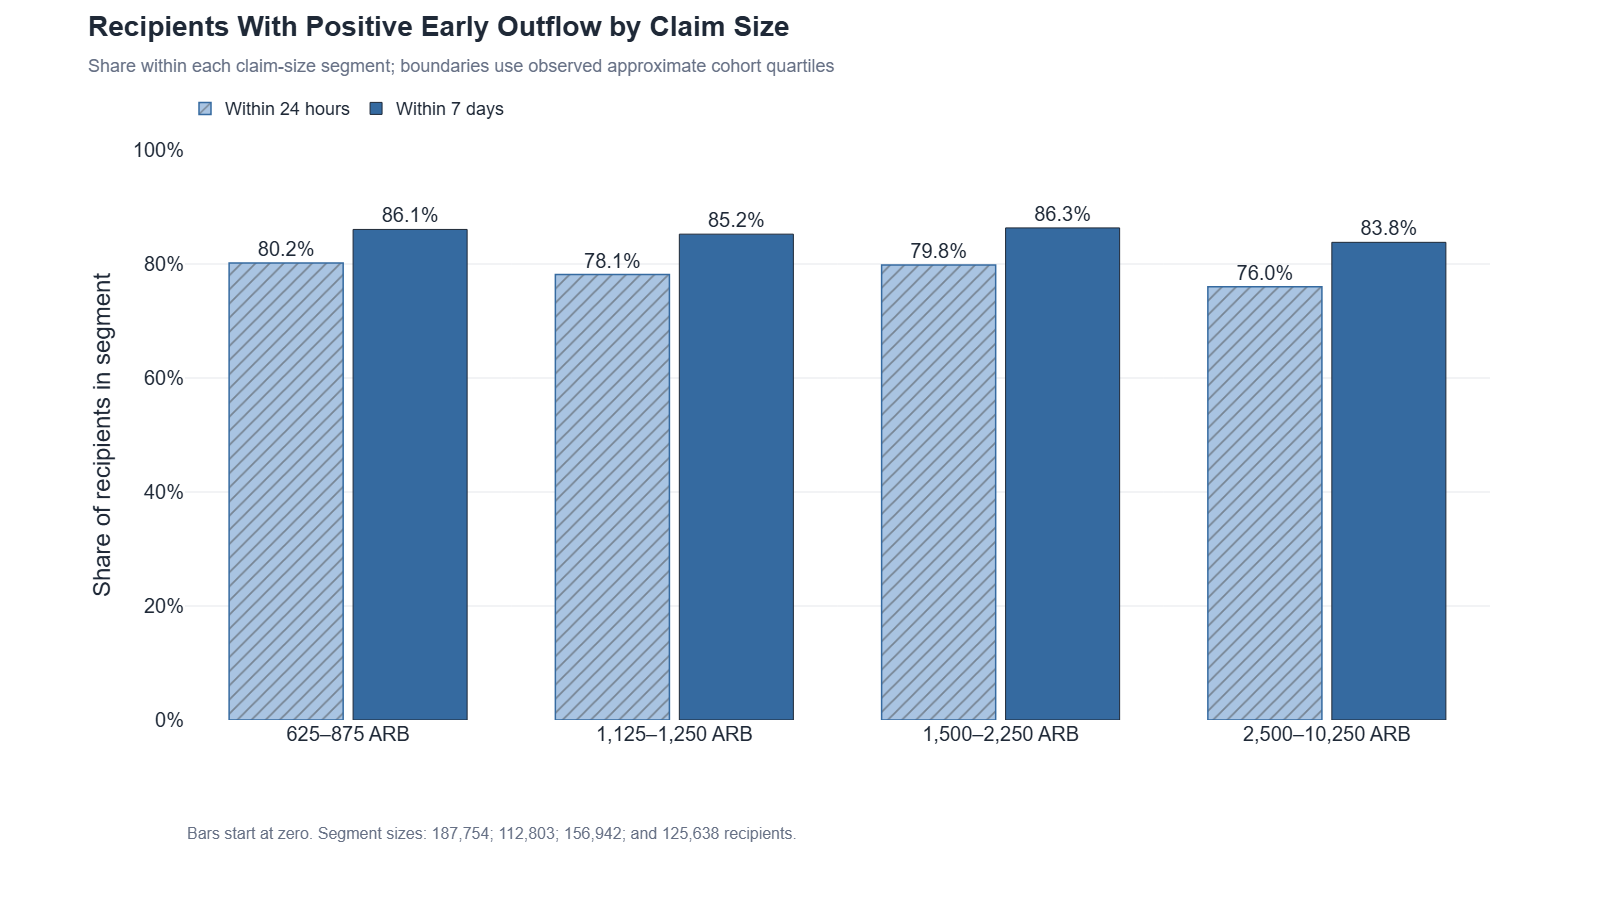

In [4]:
segment_fig = go.Figure()
segment_fig.add_bar(
    name="Within 24 hours",
    x=segment_df["claim_size_segment"],
    y=segment_df["recipient_positive_outflow_rate_24h"],
    marker=dict(
        color=COLORS["blue_light"],
        line=dict(color=COLORS["blue"], width=1.5),
        pattern=dict(shape="/", solidity=0.18),
    ),
    text=segment_df["recipient_positive_outflow_rate_24h"].map(lambda value: f"{value:.1%}"),
    textposition="outside",
    hovertemplate="%{x}<br>24 hours: %{y:.1%}<extra></extra>",
)
segment_fig.add_bar(
    name="Within 7 days",
    x=segment_df["claim_size_segment"],
    y=segment_df["recipient_positive_outflow_rate_7d"],
    marker=dict(color=COLORS["blue"], line=dict(color=COLORS["ink"], width=1)),
    text=segment_df["recipient_positive_outflow_rate_7d"].map(lambda value: f"{value:.1%}"),
    textposition="outside",
    hovertemplate="%{x}<br>7 days: %{y:.1%}<extra></extra>",
)
apply_base_layout(
    segment_fig,
    "Recipients With Positive Early Outflow by Claim Size",
    "Share within each claim-size segment; boundaries use observed approximate cohort quartiles",
    bottom_note="Bars start at zero. Segment sizes: 187,754; 112,803; 156,942; and 125,638 recipients.",
)
segment_fig.update_layout(
    barmode="group",
    bargap=0.24,
    bargroupgap=0.08,
    showlegend=True,
    legend=dict(
        orientation="h",
        x=0,
        xanchor="left",
        y=1.04,
        yanchor="bottom",
        font=dict(size=18),
    ),
)
segment_fig.update_yaxes(
    range=[0, 1],
    tickformat=".0%",
    title="Share of recipients in segment",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
segment_fig.update_xaxes(title=None, showgrid=False)
_ = export_and_display(segment_fig, "02_positive_outflow_rate_by_claim_size")

### 3. Capped claim-linked outflow and retained-claim proxy

The final chart shows a claim-amount-weighted composition. Gross wallet outflow is capped at each claim amount before aggregation, preventing other ARB balances from pushing this particular proxy above 100%.

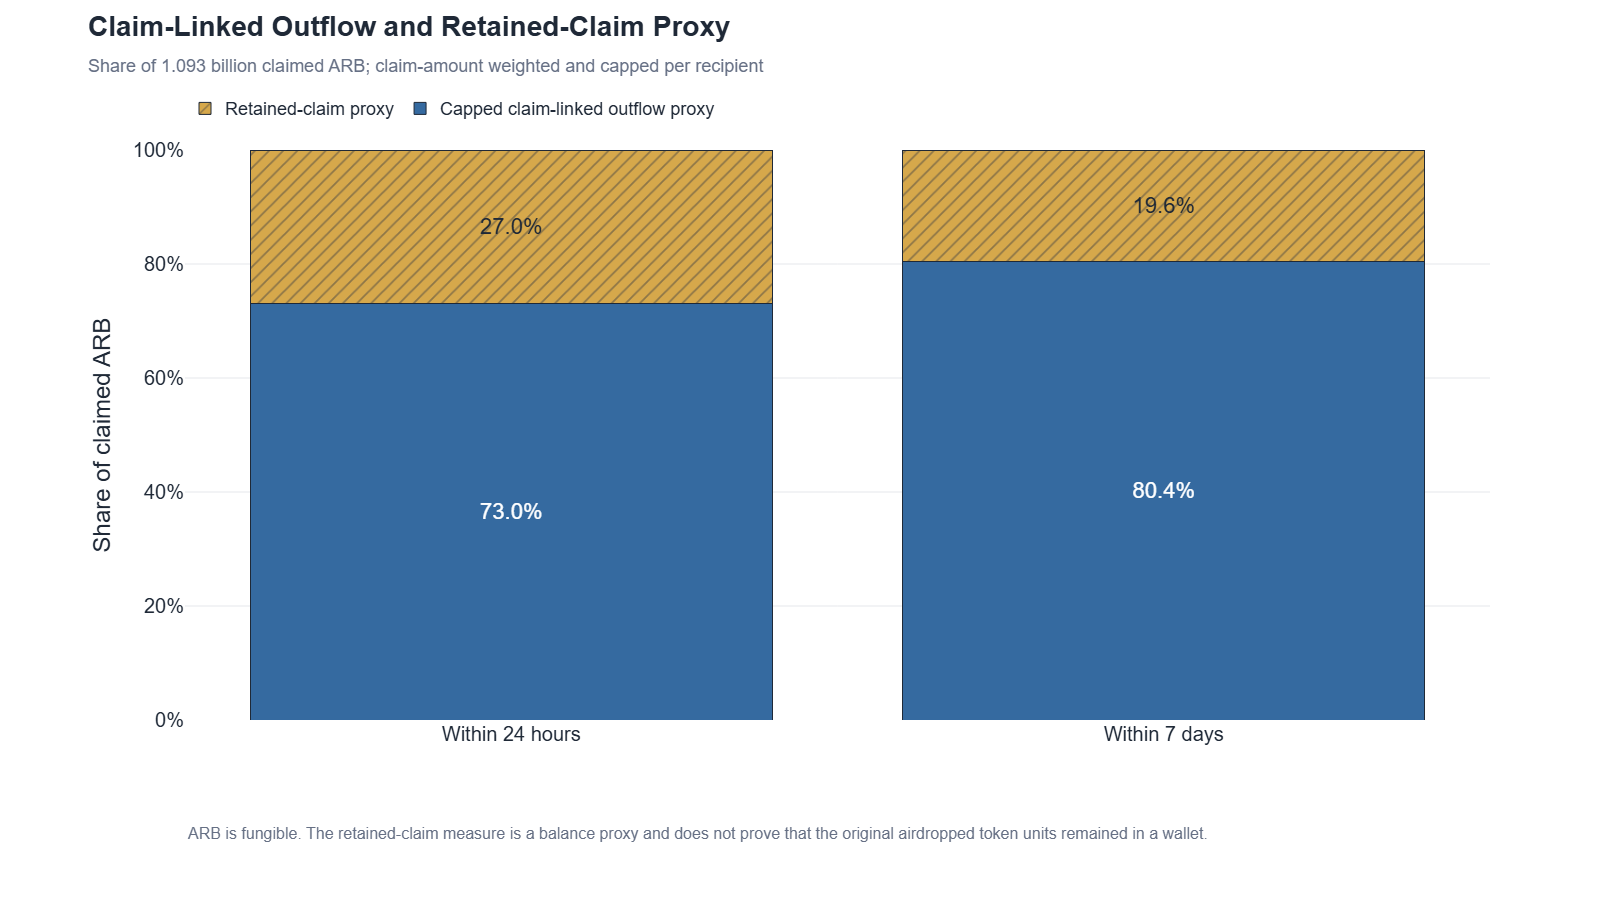

In [5]:
window_df["claim_linked_outflow_share"] = window_df["claim_linked_outflow_share"].astype(float)
window_df["retained_claim_proxy_share"] = window_df["retained_claim_proxy_share"].astype(float)

composition_fig = go.Figure()
composition_fig.add_bar(
    name="Capped claim-linked outflow proxy",
    x=window_df["window_label"],
    y=window_df["claim_linked_outflow_share"],
    marker=dict(color=COLORS["blue"], line=dict(color=COLORS["ink"], width=1)),
    text=window_df["claim_linked_outflow_share"].map(lambda value: f"{value:.1%}"),
    textposition="inside",
    insidetextanchor="middle",
    textfont=dict(color=COLORS["white"], size=22),
    hovertemplate="%{x}<br>Claim-linked outflow: %{y:.1%}<extra></extra>",
)
composition_fig.add_bar(
    name="Retained-claim proxy",
    x=window_df["window_label"],
    y=window_df["retained_claim_proxy_share"],
    marker=dict(
        color=COLORS["gold"],
        line=dict(color=COLORS["ink"], width=1),
        pattern=dict(shape="/", solidity=0.18),
    ),
    text=window_df["retained_claim_proxy_share"].map(lambda value: f"{value:.1%}"),
    textposition="inside",
    insidetextanchor="middle",
    textfont=dict(color=COLORS["ink"], size=22),
    hovertemplate="%{x}<br>Retained-claim proxy: %{y:.1%}<extra></extra>",
)
apply_base_layout(
    composition_fig,
    "Claim-Linked Outflow and Retained-Claim Proxy",
    "Share of 1.093 billion claimed ARB; claim-amount weighted and capped per recipient",
    bottom_note=(
        "ARB is fungible. The retained-claim measure is a balance proxy and does not prove that the original "
        "airdropped token units remained in a wallet."
    ),
)
composition_fig.update_layout(
    barmode="stack",
    showlegend=True,
    legend=dict(
        orientation="h",
        x=0,
        xanchor="left",
        y=1.04,
        yanchor="bottom",
        font=dict(size=18),
    ),
)
composition_fig.update_yaxes(
    range=[0, 1],
    tickformat=".0%",
    title="Share of claimed ARB",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
composition_fig.update_xaxes(title=None, showgrid=False)
_ = export_and_display(composition_fig, "03_claim_linked_outflow_composition")

## Takeaways

1. Early outflow was fast and widespread: 60.8% of recipients had a first positive outflow within one hour, and 85.5% had one within seven days.
2. Participation was high across every claim-size segment. The largest-claim segment had the lowest observed rates: 76.0% within 24 hours and 83.8% within seven days.
3. On a claim-amount-weighted basis, the capped claim-linked outflow proxy rose from 73.0% at 24 hours to 80.4% at seven days.

### Interpretation limits

- A transfer can be a sale, a deposit, a bridge, custody movement, delegation-related movement, or another action. This notebook does not classify destinations.
- Gross outflow can exceed the original claim because wallets may hold or receive other ARB. The capped proxy addresses the aggregation issue but cannot trace fungible token units.
- The charts have passed internal structural and aggregate reconciliation. No independent public benchmark for these exact full-cohort early-outflow metrics has been identified.